In [11]:
using DynamicalSystems
using DifferentialEquations
using LightGraphs
using Distributions
using LinearAlgebra
using Plots
using DelimitedFiles

In [12]:
N = 500

########## Scale free 
k = 10  ##### average degree
m = Int(k/2)
G = barabasi_albert(N,m)

######## Small world 

#k=10 ###average_degree
#psw=0.15 ### rewiring probability
#G= watts_strogatz(N,k,psw)

##### Random 
#k = 10
#edge = Int((N*k)/2.0)
#p = 0.05
#G = erdos_renyi(N,edge)

{500, 2475} undirected simple Int64 graph

In [13]:
L = laplacian_matrix(G);
writedlm("laplacian_scalefree_N=$N,k=$k.dat", L);
A = adjacency_matrix(G);
writedlm("adjacency_scalefree_1000.dat", A);

In [14]:
deg=degree(G);
sorted_indices = sortperm(deg, rev=true)
deg_sorted = deg[sorted_indices]
writedlm("deg_sorted_sf.dat", deg_sorted)

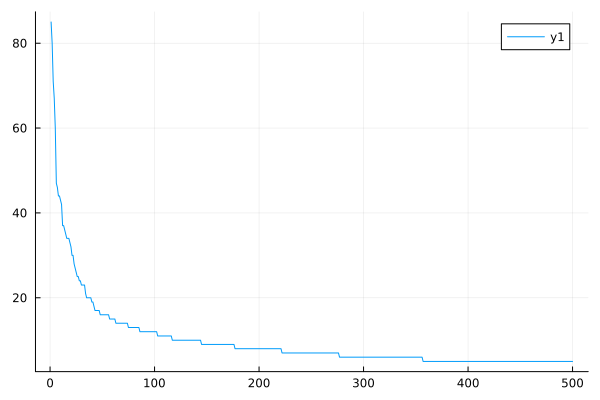

In [15]:
plot(deg_sorted)

In [16]:
### Equations of motion

function pgg1(du, u, p, t)
    
    u1=@view u[1:N]      ### N cooperators
    v1=@view u[N+1:2*N]  ##  N Defectors 
    
    du1=@view du[1:N]     
    dv1=@view du[N+1:2*N]
   
    
    r, base, d, No, kai, ϵ = p          # parameters
    
    q1=Array{Float64,1}(undef,N)   #### cooperators coupling through Laplacian
    mul!(q1,L,u1)
    
     q2=Array{Float64,1}(undef,N)  #### defectors coupling through Laplacian
    mul!(q2,L,v1)
    
    
## @. makes the all vectorized operations at once
    
   @. du1 = u1 * ((1.0 - u1 - v1) * ((r * u1 / (u1 + v1)) * (1.0 - ((1.0 - ((1.0 - u1 - v1)^ No)) / (No * (u1 + v1)))) - (1.0 + (r - 1.0) * ((1.0 - u1 - v1)^ (No - 1.0)) - (r / No) * ((1.0 - ((1.0 - u1 - v1)^ No)) / (1.0 - (1.0 - u1 - v1)))) + base) - d) - ϵ*q1

   @. dv1 = v1 * ((1.0 - u1 - v1) * ((r * u1 / (u1 + v1)) * (1.0 - ((1.0 - ((1.0 - u1 - v1)^ No)) / (No * (u1 + v1)))) + base) - d) - kai*ϵ* q2
 
    return nothing
end

pgg1 (generic function with 1 method)

In [17]:
####### setting the parameter values
r = 4.0
No = 30
d = 1.3
base = 1.0
kai = 100
ϵ = 0.01

0.01

In [18]:
####### Intial conditions and integration times
ue = 0.020078
ve = 0.102254
dist = Normal(0.0, 0.0001) 
u0=[ue .+ rand(dist,N); ve .+ rand(dist,N)] #[0.35*ones(N); 0.35*ones(N)]#
#u0=[0.09.+ rand(N); 0.14 .+ rand(N)] #[0.35*ones(N); 0.35*ones(N)]
ti=0.0
tf=1000.0
tspan=(ti,tf)
tt=900
dts=0.01

0.01

In [19]:
####### Defining the problem

prob = ODEProblem(pgg1,u0,tspan,(r, base, d, No, kai, ϵ));

In [20]:
####### solving the problem 

### here saveat is used to save at specific time duration or at specific time instances only
#### for time duration (a,b), it will be saveat=a:dts:b, where dts is the time specing at which you want to save
### for specific time instance a,  it will be saveat=[a] 
### if you want to save solution throughout the whole simulation, just remove the saveat 

#sol=solve(prob,Tsit5(),reltol=1e-15, saveat=ti:dts:tf); ## using Tsit5() solver which is adaptive solver

sol= solve(prob,RK4(), adaptive=false, dt=0.01, saveat=ti:dts:tf); ## using RK4 solver
#data = hcat(sol.t, reduce(hcat, sol.u)')  # Combine time and solution
#writedlm("solution.dat", data, ' ')       # Save in space-separated format


In [21]:
u=sol[1:N,end]
v=sol[N+1:2*N,end];

In [22]:
u_sorted =  [u[i] for i in sorted_indices]

500-element Vector{Float64}:
 0.18026213213582185
 0.15586041577881965
 0.18270841509894253
 0.15261362107950677
 0.14405160942331613
 0.23460881571337405
 0.11236906374731374
 0.21104810575852426
 0.23489660624809144
 0.0664098711663677
 0.21410215838535357
 0.2533099818273669
 0.22943202929779577
 ⋮
 0.011166307586359026
 0.011365086041074574
 0.26416525067889063
 0.011630003950198227
 0.012545242684847113
 0.019721737593560034
 0.018113927472386753
 0.010294919950177785
 0.015895558048484693
 0.28300739960213794
 0.017774445353019398
 0.004553786255085253

In [23]:
v_sorted=   [v[i] for i in sorted_indices]

500-element Vector{Float64}:
 0.1716530703274331
 0.17034963887630705
 0.17218517950728449
 0.1693387774137934
 0.16897931251086623
 0.17215667811576058
 0.16877625072818506
 0.17062828942624672
 0.17159462467443373
 0.16638032446483428
 0.17176315402221085
 0.17235768238635762
 0.17187222705851285
 ⋮
 0.15943502731287196
 0.157601226431707
 0.19647876481082377
 0.15837469633239837
 0.15863621720895577
 0.16568987314133043
 0.16258100536289205
 0.15749155382132668
 0.1614807087238258
 0.18799598912918833
 0.16355065528149385
 0.15275074531269037

In [24]:
uu = [mean(u_sorted) mean(v_sorted)]


1×2 Matrix{Float64}:
 0.100737  0.167299

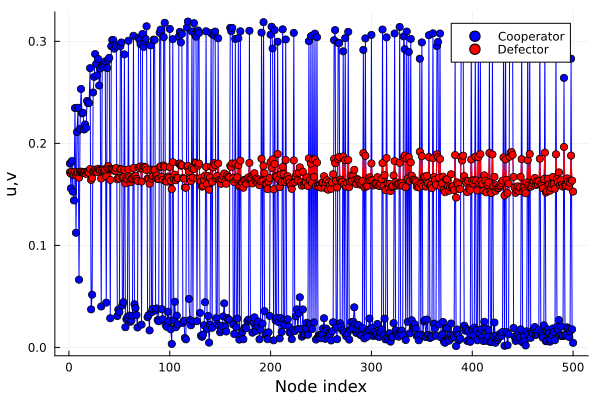

In [25]:
p=plot(u_sorted,label="", c="blue")
scatter!(u_sorted,label="Cooperator", c="blue")
plot!(v_sorted,label="", c="red")
scatter!(v_sorted,label="Defector", c="red")

xlabel!("Node index")   
ylabel!("u,v") 

##title!("Plot Title")      
#ylims!(-0.00000001, 0.0000001)

savefig(p,"figure0.png")  # Saves as a PNG file
display(p)

In [26]:
# Define node indices (1 to N)
node_index = 1:N

# Extract cooperator and defector data from solution
x_data = sol[1:N, end]          # Last time step data for cooperators
y_data = sol[N+1:2*N, end]      # Last time step data for defectors

# Combine into a single matrix for saving
data = hcat(node_index, x_data, y_data)

# Save to a .dat file with space-separated values
writedlm("datasf_r=$r kappa=$kai.dat", data, ' ')


In [27]:
# Define node indices (1 to N)
node_index = 1:N

# Extract cooperator and defector data from solution
x_data = sol[1:N, end]          # Last time step data for cooperators
y_data = sol[N+1:2*N, end]      # Last time step data for defectors

# Create binary column (1 where x > y, 0 otherwise)
binary_data = Int.(x_data .> y_data)

# Combine into a single matrix for saving
data = hcat(node_index, x_data, y_data, binary_data)

# Save to a .dat file with space-separated values
writedlm("datasf_binary_node=500.dat", data, ' ')

In [18]:
#plot(sol[N+1:2*N]',label="")

In [44]:
#plot(sol[1:N,end-100:end]',label="")
#plot(sol[N+1:2*N,end-100:end]',label="")

In [45]:
# Define the degree vector (D) and solution vector (x)
D = [3, 1, 4, 2, 5]  # Degrees
x = [0.3, 0.1, 0.4, 0.2, 0.5]  # Corresponding solutions

# Get sorted indices based on D in descending order
sorted_indices = sortperm(D, rev=true)

# Use correct indexing to sort D and x
D_sorted = D[sorted_indices]  # Sorted degrees
x_sorted = [x[i] for i in sorted_indices]  # Sorted x

# Print results
println("Sorted degrees: ", D_sorted)
println("Sorted x: ", x_sorted)


Sorted degrees: [5, 4, 3, 2, 1]
Sorted x: [0.5, 0.4, 0.3, 0.2, 0.1]


In [46]:
sorted_indices

5-element Vector{Int64}:
 5
 3
 1
 4
 2

In [1]:
import Pkg; 
Pkg.add("Symbolics")
Pkg.add("NLsolve")

    Updating registry at `C:\Users\SOURAV\.julia\registries\General.toml`
   Resolving package versions...
  No Changes to `C:\Users\SOURAV\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\SOURAV\.julia\environments\v1.10\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\SOURAV\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\SOURAV\.julia\environments\v1.10\Manifest.toml`


In [10]:

using Symbolics, NLsolve

# Define parameters
r = 4.0
No = 30
base = 1.0
d = 1.3

# Define the system of equations
function equations(vars)
    u, v = vars
    xdot = u * ((1.0 - u - v) * ((r * u / (u + v)) * (1.0 - ((1.0 - ((1.0 - u - v)^No)) / (No * (u + v)))) -
           (1.0 + (r - 1.0) * ((1.0 - u - v)^(No - 1.0)) - (r / No) * ((1.0 - ((1.0 - u - v)^No)) / (1.0 - (1.0 - u - v)))) +
           base) - d)

    ydot = v * ((1.0 - u - v) * ((r * u / (u + v)) * (1.0 - ((1.0 - ((1.0 - u - v)^No)) / (No * (u + v)))) + base) - d)

    return [xdot, ydot]
end

# Solve numerically
sol = nlsolve(equations, [0.5, 0.5])  # Initial guess

# Display results
println("u = ", sol.zero[1])
println("v = ", sol.zero[2])


u = 0.020078355266748595
v = 0.10225378559343869
